<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/Gradient_Descnet_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

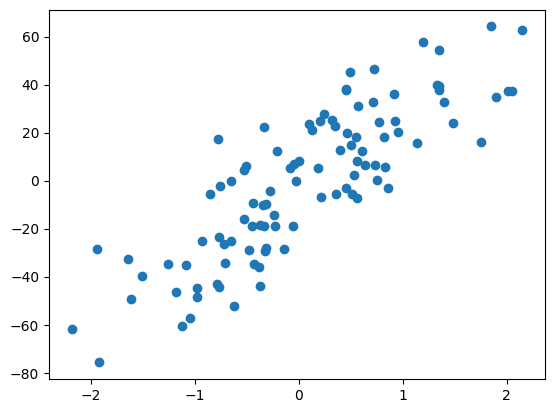

In [3]:
plt.scatter(X,y)

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
lr=LinearRegression()

In [8]:
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783825


In [9]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012

In [15]:
import numpy as np

class GDRegressor:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.W = None
        self.b = None
        self.losses = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # initialize weights
        self.W = np.zeros(n_features)
        self.b = 0

        for i in range(self.epochs):
            y_pred = np.dot(X, self.W) + self.b

            # compute loss (MSE)
            loss = np.mean((y - y_pred) ** 2)
            self.losses.append(loss)

            # gradients
            dW = -(2/n_samples) * np.dot(X.T, (y - y_pred))
            db = -(2/n_samples) * np.sum(y - y_pred)

            # update
            self.W -= self.lr * dW
            self.b -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.W) + self.b

In [18]:
model = GDRegressor(lr=0.01, epochs=1000)
model.fit(X_train, y_train)

In [ ]:
gd=GDRegressor()

In [12]:
gd.fit(X_train,y_train)

28.159367347119066 -2.3004574196824854


In [14]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6343842836315579

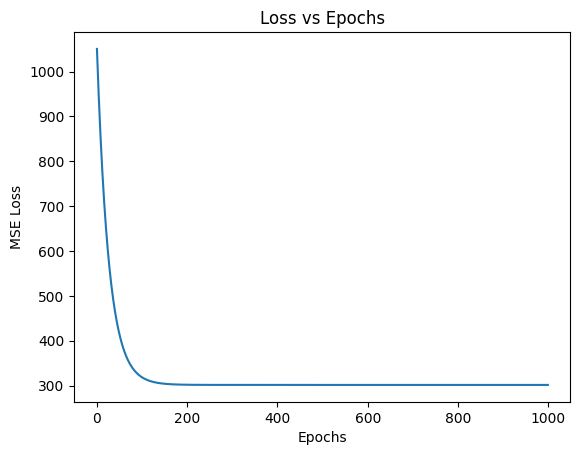

In [19]:
import matplotlib.pyplot as plt

plt.plot(model.losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

#Train & Compare with scikit-learn

In [20]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# create dataset
X, y = make_regression(n_samples=200, n_features=3, noise=20, random_state=42)

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# train custom model
model = GDRegressor(lr=0.01, epochs=1000)
model.fit(X_train, y_train)

y_pred_custom = model.predict(X_test)

# sklearn model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_sklearn = lr.predict(X_test)

# compare
print("Custom Model R2:", r2_score(y_test, y_pred_custom))
print("Sklearn Model R2:", r2_score(y_test, y_pred_sklearn))

print("Custom MSE:", mean_squared_error(y_test, y_pred_custom))
print("Sklearn MSE:", mean_squared_error(y_test, y_pred_sklearn))

Custom Model R2: 0.9594054001878801
Sklearn Model R2: 0.9594053987042758
Custom MSE: 363.06275605860975
Sklearn MSE: 363.0627693274061


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
class GDRegressorEarlyStop:
    def __init__(self, lr=0.01, epochs=1000, tol=1e-4):
        self.lr = lr
        self.epochs = epochs
        self.tol = tol
        self.losses = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.W = np.zeros(n_features)
        self.b = 0

        prev_loss = float('inf')

        for i in range(self.epochs):
            y_pred = np.dot(X, self.W) + self.b

            loss = np.mean((y - y_pred) ** 2)
            self.losses.append(loss)

            if abs(prev_loss - loss) < self.tol:
                print(f"Stopped early at epoch {i}")
                break

            prev_loss = loss

            dW = -(2/n_samples) * np.dot(X.T, (y - y_pred))
            db = -(2/n_samples) * np.sum(y - y_pred)

            self.W -= self.lr * dW
            self.b -= self.lr * db

In [23]:
class SGDRegressor:
    def __init__(self, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.W = np.zeros(n_features)
        self.b = 0

        for epoch in range(self.epochs):
            for i in range(n_samples):
                idx = np.random.randint(0, n_samples)
                xi = X[idx]
                yi = y[idx]

                y_pred = np.dot(xi, self.W) + self.b

                dW = -2 * xi * (yi - y_pred)
                db = -2 * (yi - y_pred)

                self.W -= self.lr * dW
                self.b -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.W) + self.b

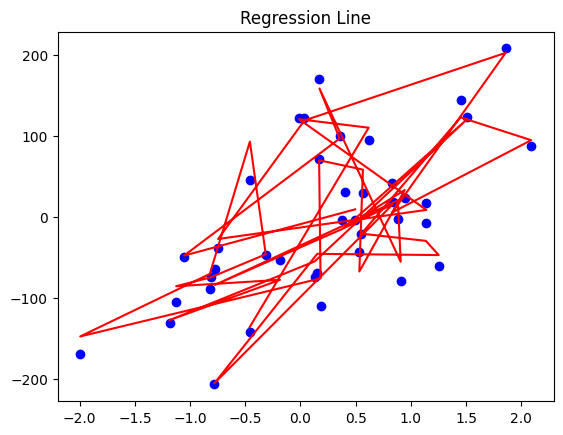

In [24]:
plt.scatter(X_test[:, 0], y_test, color='blue')
plt.plot(X_test[:, 0], y_pred_custom, color='red')
plt.title("Regression Line")
plt.show()